In [23]:
import numpy as np
from qiskit.circuit import Gate, QuantumCircuit
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator

In [24]:
state = np.array([1, 2, 15, 1])
state = state / np.linalg.norm(state)
prep = StatePreparation(state, normalize=False)
prep.name

'state_preparation'

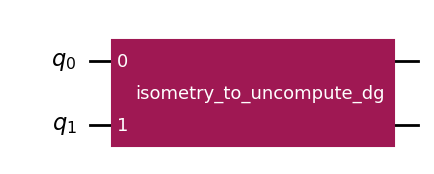

In [25]:
circ: QuantumCircuit = prep.definition
circ.draw("mpl", fold=-1)

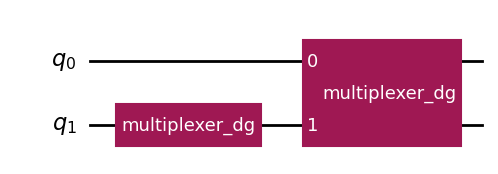

In [26]:
circ.decompose(reps=1).draw("mpl", fold=-1)

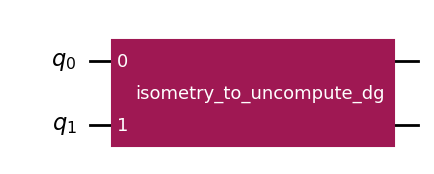

In [27]:
circ.draw("mpl", fold=-1)

In [28]:
op = Operator(circ)
op.data

array([[ 6.57951695e-02+0.00000000e+00j,  3.46944695e-17+1.31590339e-01j,
        -4.42347144e-01+5.55111512e-17j, -2.49800181e-16-8.84694288e-01j],
       [ 1.31590339e-01-2.77555756e-17j, -4.16333634e-17-6.57951695e-02j,
        -8.84694288e-01+2.22044605e-16j,  3.33066907e-16+4.42347144e-01j],
       [ 9.86927542e-01+1.11022302e-16j, -1.11022302e-16-6.57951695e-02j,
         1.46796619e-01+1.38777878e-17j, -2.77555756e-17-9.78644124e-03j],
       [ 6.57951695e-02+0.00000000e+00j,  8.32667268e-17+9.86927542e-01j,
         9.78644124e-03+0.00000000e+00j,  0.00000000e+00+1.46796619e-01j]])

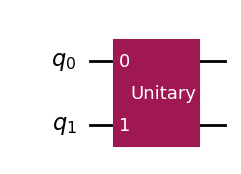

In [29]:
ccc = QuantumCircuit(op.num_qubits)

ccc.append(op, ccc.qubits)
ccc.draw("mpl")

In [30]:
op.to_instruction()

Instruction(name='unitary', num_qubits=2, num_clbits=0, params=[array([[ 6.57951695e-02+0.00000000e+00j,  3.46944695e-17+1.31590339e-01j,
        -4.42347144e-01+5.55111512e-17j, -2.49800181e-16-8.84694288e-01j],
       [ 1.31590339e-01-2.77555756e-17j, -4.16333634e-17-6.57951695e-02j,
        -8.84694288e-01+2.22044605e-16j,  3.33066907e-16+4.42347144e-01j],
       [ 9.86927542e-01+1.11022302e-16j, -1.11022302e-16-6.57951695e-02j,
         1.46796619e-01+1.38777878e-17j, -2.77555756e-17-9.78644124e-03j],
       [ 6.57951695e-02+0.00000000e+00j,  8.32667268e-17+9.86927542e-01j,
         9.78644124e-03+0.00000000e+00j,  0.00000000e+00+1.46796619e-01j]])])

In [31]:
op_adj = op.adjoint()
op_adj

Operator([[ 6.57951695e-02-0.00000000e+00j,
            1.31590339e-01+2.77555756e-17j,
            9.86927542e-01-1.11022302e-16j,
            6.57951695e-02-0.00000000e+00j],
          [ 3.46944695e-17-1.31590339e-01j,
           -4.16333634e-17+6.57951695e-02j,
           -1.11022302e-16+6.57951695e-02j,
            8.32667268e-17-9.86927542e-01j],
          [-4.42347144e-01-5.55111512e-17j,
           -8.84694288e-01-2.22044605e-16j,
            1.46796619e-01-1.38777878e-17j,
            9.78644124e-03-0.00000000e+00j],
          [-2.49800181e-16+8.84694288e-01j,
            3.33066907e-16-4.42347144e-01j,
           -2.77555756e-17+9.78644124e-03j,
            0.00000000e+00-1.46796619e-01j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [32]:
inv = prep.inverse()
inv.name

'state_preparation_dg'

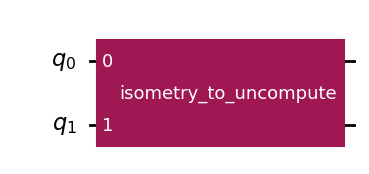

In [33]:
inv_circ: QuantumCircuit = inv.definition
inv_circ.draw("mpl", fold=-1)

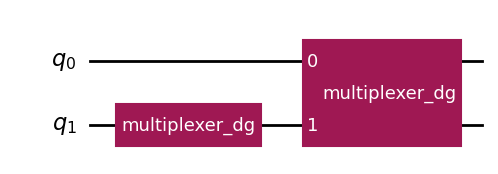

In [34]:
circ.decompose(reps=1).draw("mpl", fold=-1)

In [35]:
inv_op = Operator(inv_circ)
inv_op.data

array([[ 6.57951695e-02-9.02914433e-18j,  1.31590339e-01-2.21417575e-17j,
         9.86927542e-01-3.97833215e-16j,  6.57951695e-02-1.17118920e-16j],
       [-9.89135089e-18-1.31590339e-01j, -2.36386067e-17+6.57951695e-02j,
        -4.76023634e-17+6.57951695e-02j, -2.33111931e-16-9.86927542e-01j],
       [-4.42347144e-01+6.07037908e-17j, -8.84694288e-01+1.48861129e-16j,
         1.46796619e-01-5.91741219e-17j,  9.78644124e-03-1.74203888e-17j],
       [ 6.65004870e-17+8.84694288e-01j,  1.58924588e-16-4.42347144e-01j,
        -7.08042453e-18+9.78644124e-03j, -3.46733086e-17-1.46796619e-01j]])

In [36]:
inv_op.to_instruction()

Instruction(name='unitary', num_qubits=2, num_clbits=0, params=[array([[ 6.57951695e-02-9.02914433e-18j,  1.31590339e-01-2.21417575e-17j,
         9.86927542e-01-3.97833215e-16j,  6.57951695e-02-1.17118920e-16j],
       [-9.89135089e-18-1.31590339e-01j, -2.36386067e-17+6.57951695e-02j,
        -4.76023634e-17+6.57951695e-02j, -2.33111931e-16-9.86927542e-01j],
       [-4.42347144e-01+6.07037908e-17j, -8.84694288e-01+1.48861129e-16j,
         1.46796619e-01-5.91741219e-17j,  9.78644124e-03-1.74203888e-17j],
       [ 6.65004870e-17+8.84694288e-01j,  1.58924588e-16-4.42347144e-01j,
        -7.08042453e-18+9.78644124e-03j, -3.46733086e-17-1.46796619e-01j]])])

In [37]:
np.allclose(op.data.conj().T, inv_op.data)

True

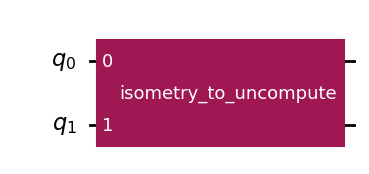

In [38]:
direct_inv = StatePreparation(state, inverse=True, normalize=False)
direct_inv_circ: QuantumCircuit = direct_inv.definition
direct_inv_circ.draw("mpl", fold=-1)

In [39]:
direct_inv_op = Operator(direct_inv_circ)
direct_inv_op.data

array([[ 6.57951695e-02-9.02914433e-18j,  1.31590339e-01-2.21417575e-17j,
         9.86927542e-01-3.97833215e-16j,  6.57951695e-02-1.17118920e-16j],
       [-9.89135089e-18-1.31590339e-01j, -2.36386067e-17+6.57951695e-02j,
        -4.76023634e-17+6.57951695e-02j, -2.33111931e-16-9.86927542e-01j],
       [-4.42347144e-01+6.07037908e-17j, -8.84694288e-01+1.48861129e-16j,
         1.46796619e-01-5.91741219e-17j,  9.78644124e-03-1.74203888e-17j],
       [ 6.65004870e-17+8.84694288e-01j,  1.58924588e-16-4.42347144e-01j,
        -7.08042453e-18+9.78644124e-03j, -3.46733086e-17-1.46796619e-01j]])

In [40]:
np.allclose(direct_inv_op.data, inv_op.data)

True

In [41]:
np.allclose(op_adj.data, inv_op.data)

True

In [42]:
simulator = AerSimulator()
decomposed_circ = circ.decompose(reps=2)
decomposed_gate = decomposed_circ.to_gate()
job = simulator.run(decomposed_gate.definition)
result = job.result()

In [43]:
result.success

True

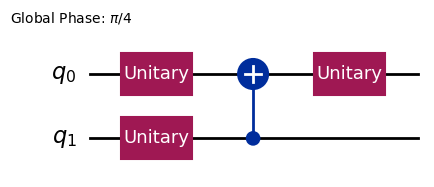

In [44]:
decomposed_gate.definition.draw("mpl", fold=-1)